# **Solemne 1**

### **1 Selección de Datos**
---
Se ha seleccionado el dataset *fdic_banks* debido a que el sistema bancario de EE.UU. es un sistema dinámico que ha enfrentado diversas crisis (aunque aún no conozco las fechas de los datos). Mediante técnicas de minería de datos, se busca explorar cómo estas problemáticas se reflejan en la evolución de los activos totales y en la tasa de cierre de instituciones, permitiendo generar evidencia para la toma de decisiones en escenarios de estrés financiero similares a futuro en situaciones similares.

---

In [1]:
#importo librerias que considero utiles para el analisis de datos
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#Conectamos con GBQ
project_id = 'poised-artwork-489418-c3'
client = bigquery.Client(project=project_id)

c:\Users\bg_go\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\auth\_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


## 2. Importación de Datos

Para la selección de variables, se realizó una inspección previa del esquema (metadata) del dataset bigquery-public-data.fdic_banks.institutions. Se identificaron como críticas aquellas variables que permiten modelar el comportamiento del sistema (activos) y su evolución cronológica (fechas), asegurando que la extracción cubra todos los requisitos analíticos de la evaluación.

---

Desde GBQ he visto los las tablas que contiene *fdic-banks* e imprimo los *schemas* para saber que tipos de datos debería trabajar.

---

In [3]:
# Para ver las columnas de institutions
print("Columnas de Institutions:", client.get_table("bigquery-public-data.fdic_banks.institutions").schema)

# Para ver las columnas de locations
#print("Columnas de Locations:", client.get_table("bigquery-public-data.fdic_banks.locations").schema)

Columnas de Institutions: [SchemaField('fdic_certificate_number', 'STRING', 'NULLABLE', None, 'A unique number assigned by the FDIC used to identify institutions and for the issuance of insurance certificates.', (), None, None), SchemaField('institution_name', 'STRING', 'NULLABLE', None, 'The legal name of the institution.', (), None, None), SchemaField('state_name', 'STRING', 'NULLABLE', None, 'State in which the the institution is physically located. The FDIC Act defines state as any State of the United States, the District of Columbia, and any territory of the United States, Puerto Rico, Guam, American Samoa, the Trust Territory of the Pacific Islands, the Virgin Island, and the Northern Mariana Islands.', (), None, None), SchemaField('fdic_id', 'STRING', 'NULLABLE', None, "FDIC's unique identifier number for holding companies, banks, branches and nondeposit subsidiaries.", (), None, None), SchemaField('docket', 'STRING', 'NULLABLE', None, 'An identification number assigned to insti

---
En este caso he escogido la tabla de Institutions ya que considero que podrían tener más información sobre lo que se quiere analizar. Ahora extraemos los datos.

---

In [16]:
# query basada en el schema de Institutions
query = """
SELECT 
    institution_name, 
    state_name, 
    established_date, 
    total_assets, 
    total_deposits,
    active
FROM `bigquery-public-data.fdic_banks.institutions`
WHERE total_assets > 0
"""

df = client.query(query).to_dataframe()

#vemos si los datos se han cargado correctamente
#print(df.head())

c:\Users\bg_go\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


---
Ahora vemos que tipos de datos y cuantos hay por carácterística.

---

In [17]:
print(f"Dimensiones (filas, columnas): {df.shape}")
print("\n--- Tipos de datos por columna ---")
print(df.dtypes)
print("\n--- Conteo de valores nulos ---")
print(df.isnull().sum())

#Revisamos header
df.head()

Dimensiones (filas, columnas): (23810, 6)

--- Tipos de datos por columna ---
institution_name     object
state_name           object
established_date     dbdate
total_assets          Int64
total_deposits        Int64
active              boolean
dtype: object

--- Conteo de valores nulos ---
institution_name    0
state_name          0
established_date    0
total_assets        0
total_deposits      0
active              0
dtype: int64


,institution_name,state_name,established_date,total_assets,total_deposits,active
0,Baldwin County Federal Savings Bank,Alabama,1927-01-01,139961,137777,False
1,First Federal Savings and Loan Association of ...,Alabama,1990-12-28,29306,30666,False
2,First Federal Savings and Loan Association,Alabama,1934-08-01,38693,37738,False
3,Coosa Federal Savings and Loan Association,Alabama,1960-08-05,72057,76164,False
4,Jefferson Federal Savings and Loan Association...,Alabama,1991-03-08,437047,355021,False


---
Aquí veo que los datos están correctamente añadidos a mi data frame, (se parecen mucho a lo que ví desde la consola de GBQ). Además se puede ver no existen datos vacíos (null) (lo que nos puede decir que este datset ya fue limpiado quizás, no estoy seguro).

---

Como primera observación puedo ver que la tabla tiene una columna de *Fechas*, *Activos (Assets)* y *depósitos*. Si bien hay muchos hitos importantes en la historia financiera de EE.UU. es importante saber en que rango se encuentra nuestro dataset. Al definir esto podemos ver cómo la gran recesión de EEUU afectó las *transacciones* y la venta de *activos*.


In [18]:
df['established_date'] = pd.to_datetime(df['established_date'])

#Calcular los valores extremos
fecha_minima = df['established_date'].min()
fecha_maxima = df['established_date'].max()

print(f"La institución más antigua data de: {fecha_minima}")
print(f"La fecha más reciente en el dataset es: {fecha_maxima}")

intervalo_anios = fecha_maxima.year - fecha_minima.year
print(f"El dataset cubre un periodo de {intervalo_anios} años.")

La institución más antigua data de: 1782-01-01 00:00:00
La fecha más reciente en el dataset es: 2022-06-21 00:00:00
El dataset cubre un periodo de 240 años.


## **3. Preguntas Analíticas** 
**P1. ¿Cómo decayeron la poseción de activos en los bancos de EE.UU durante la crisis económica?** 

**P2. ¿Es realmente la cantidad de depósitos bancarios un índice de crisis?**

---

Para responder estas preguntas se debe hacer un filtrado de datos puesto que nuestra época de interés es mucho más pequeña que 240 años, y datos muy antiguos pueden ser engañosos.

---

In [19]:
df_filtrado = df[df['established_date'] >= '1970-01-01'].copy()

#Verificamos cuánto cambió nuestro sistema
print(f"Registros originales: {len(df)}")
print(f"Registros después del filtro: {len(df_filtrado)}")
print(f"Nuevo rango: {df_filtrado['established_date'].min().year} a {df_filtrado['established_date'].max().year}")

#Reasignamos el data set para diferenciarlo del original
df = df_filtrado

Registros originales: 23810
Registros después del filtro: 8807
Nuevo rango: 1970 a 2022




Si bien la cantida de datos bajó esto se puede deber a la digitalización los bancos. Ahora me gustaría saber cual es la cantidad de activos y depositos para luego agruparlos por un rango de años.

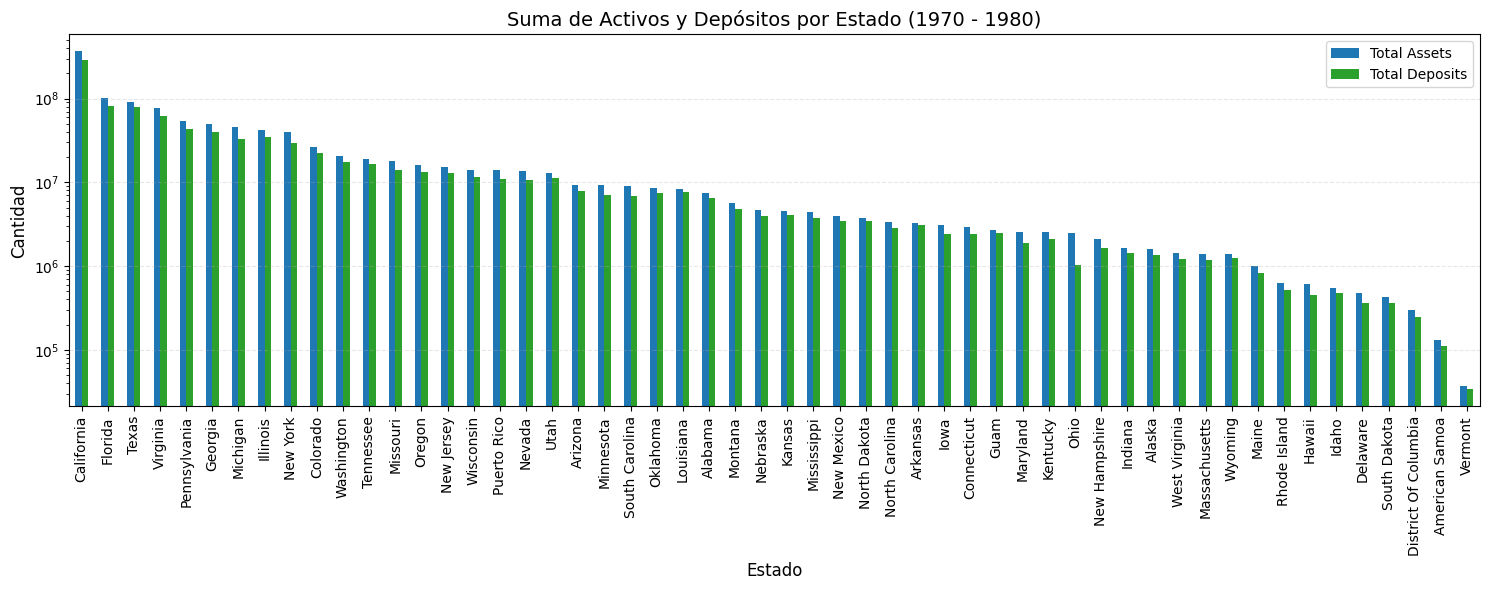

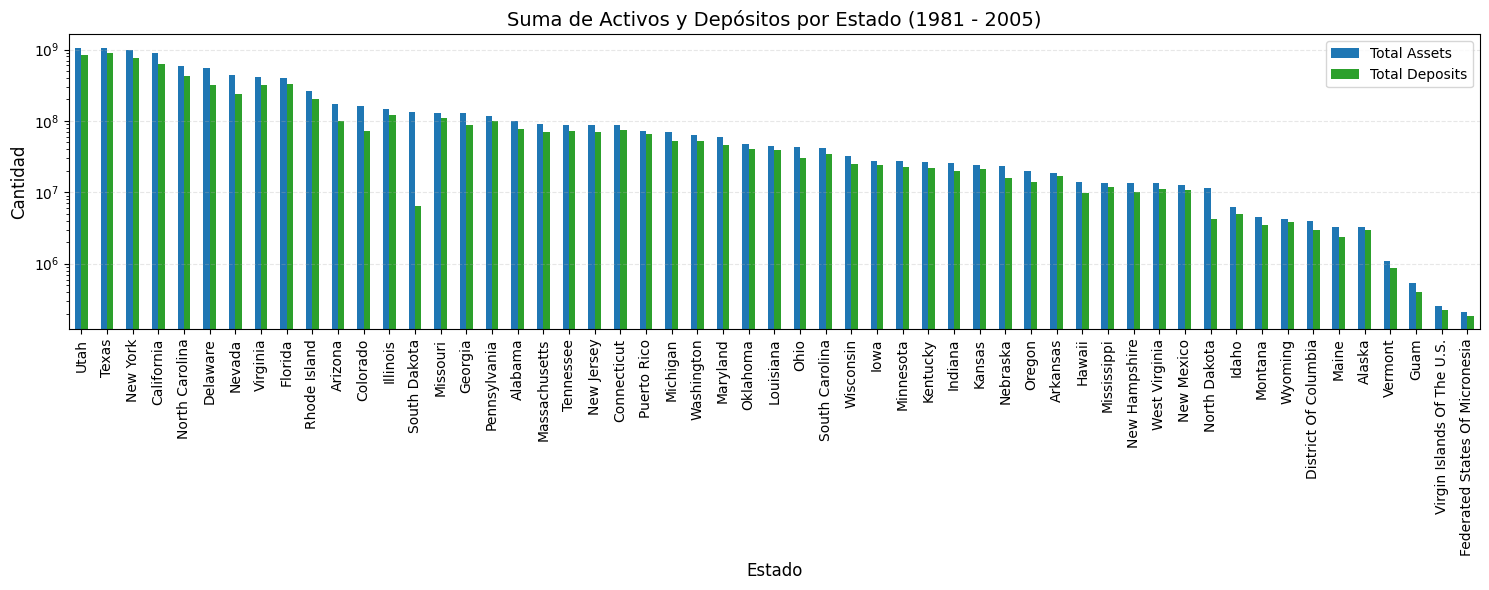

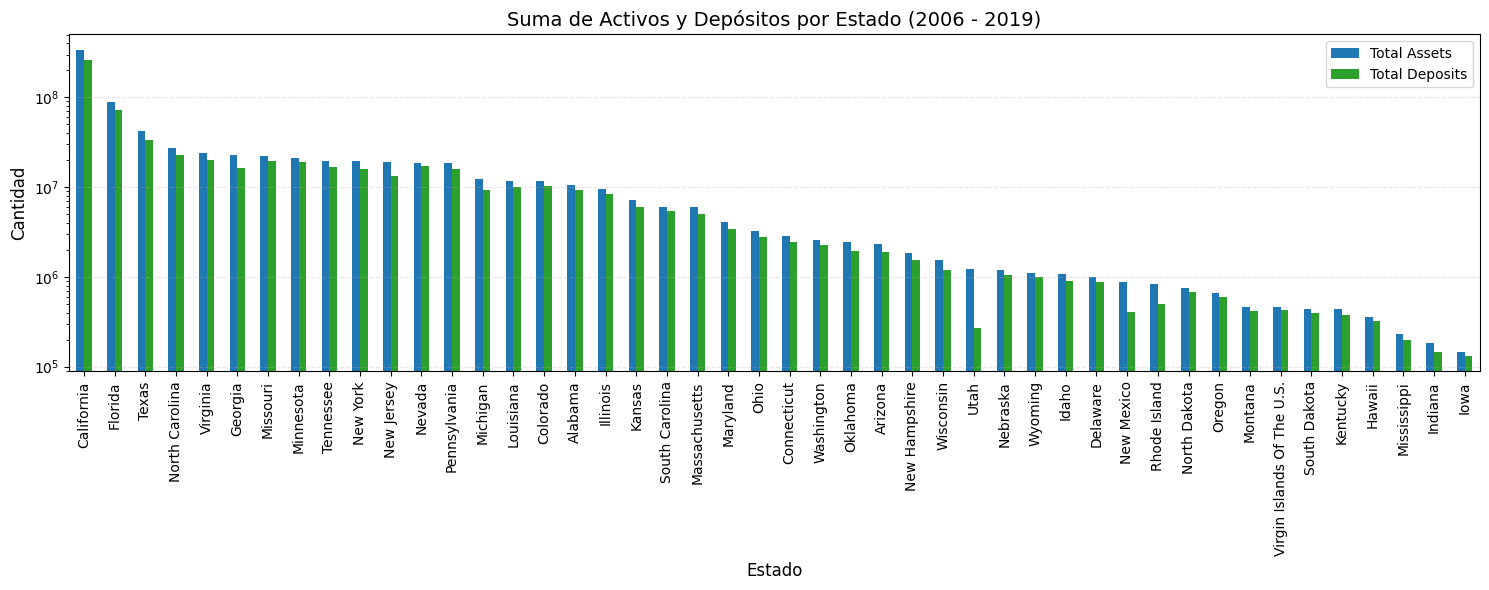

In [27]:
#Realizaré un codigo para realizar un histograma por peridos.

periodos = [
    (1970, 1980, "Periodo 1: 1970 - 1980"),
    (1981, 2005, "Periodo 2: 1981 - 2005"),
    (2006, 2019, "Periodo 3: 2006 - 2019")
]

import pandas as pd
import matplotlib.pyplot as plt

# 1. Aseguramos que existan las columnas necesarias
df['established_date'] = pd.to_datetime(df['established_date'])
df['year'] = df['established_date'].dt.year

# 2. Definimos los periodos
periodos = [
    (1970, 1980, "1970 - 1980"),
    (1981, 2005, "1981 - 2005"),
    (2006, 2019, "2006 - 2019")
]

# 3. EL BUCLE (Atención a la sangría después de los ':')
for inicio, fin, titulo in periodos:

    # Filtramos usando la columna 'year' que es más simple
    df_periodo = df[(df['year'] >= inicio) & (df['year'] <= fin)].copy()
    
    # Agrupamos por estado
    resumen_estado = df_periodo.groupby('state_name')[['total_assets', 'total_deposits']].sum()
    
    # Solo graficamos si hay datos en ese periodo
    if not resumen_estado.empty:
        # Ordenamos por activos para que el eje X se vea profesional
        resumen_estado = resumen_estado.sort_values(by='total_assets', ascending=False)
        
        # Crear gráfico de barras
        resumen_estado.plot(kind='bar', figsize=(15, 6), color=['#1f77b4', '#2ca02c'])
        
        plt.yscale('log')  # para que no se vea la barra gigante de algun estado

        plt.title(f'Suma de Activos y Depósitos por Estado ({titulo})', fontsize=14)
        plt.xlabel('Estado', fontsize=12)
        plt.ylabel('Cantidad', fontsize=12)
        plt.xticks(rotation=90) #para que quepan todos los estados y vea bonito
        plt.legend(["Total Assets", "Total Deposits"])
        plt.grid(axis='y', linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No se encontraron datos para el periodo {titulo}")

---

### **Observaciones:**

1. Se puede observar que la mayor cantidad de depósitos y activos la tiene el estado California en los distintos periodos observados.

2. Además la cantidad de activos y depósitos fue mucho más alta durante el periodo de 1981-2005

3. Luego del 2006 estos bajan en cantidades esto se puede interpretar ya que durante el 2007 y 2008 ocurrió la Gran Recesión de EE.UU donde hubo alto desempleo por lo tanto bajos depósitos y quizás la venta de muchos activos como medida desesperada de los bancos para sobreyevar la inflación.

---

### **Conclusión**

Con poca seguridad puedo inferir que la cantidad de activos y depósitos son indicadores de lo proximidad de alguna crisis económica, sin embargo se puede ver que los estados de California y New York actúan como los principales atractores de capital. 

Algo que no esperaba ver es que la proporción entre activos y depósitos se mantiene casi constantes a través de los tres periodos y que no dependen de las cantidades que los estados tengan.

Si bien al inicio nuestro código mostró cero datos nulos esto también se debería tener en consideración ya que la muestra de datos es completamente variable. Además con la tabla no explorada de locations del dataset *fdic_banks* quizás se puede ver donde hay desiertos financieros que exisitieron en algunos periodos.
